# 08｜研究延伸與常見陷阱

**本檔為自編補充實驗**，回應延伸課綱中的 NFL、資料洩漏、Data Mismatch、概念漂移與穩健指標。各節可獨立討論，建議課後 45–60 分鐘，不另加進原三週九小時主線。

以合成資料隔離機制，所有生成條件與 seed 可見；這些結果不代表真實資料上的普遍勝負。延續前面兩個 GitHub 教材的 LinearRegression、k-NN、Pipeline、SGD 與驗證框架，沒有把合成實驗標成來源教材的原始結果。

API／流程參考：[scikit-learn 1.7 常見陷阱](https://scikit-learn.org/1.7/common_pitfalls.html)、[交叉驗證文件](https://scikit-learn.org/1.7/modules/cross_validation.html)。來源快照詳見 [SOURCES.md](../SOURCES.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 沒有單一模型在所有問題都最好：兩個反例

讓線性模型與 k-NN 在「直線」與「波浪」函數上比較。這只能呈現歸納偏好如何配合問題；有限實驗不是 No Free Lunch 定理的證明，也不表示在特定問題族中無法找到表現良好的方法。

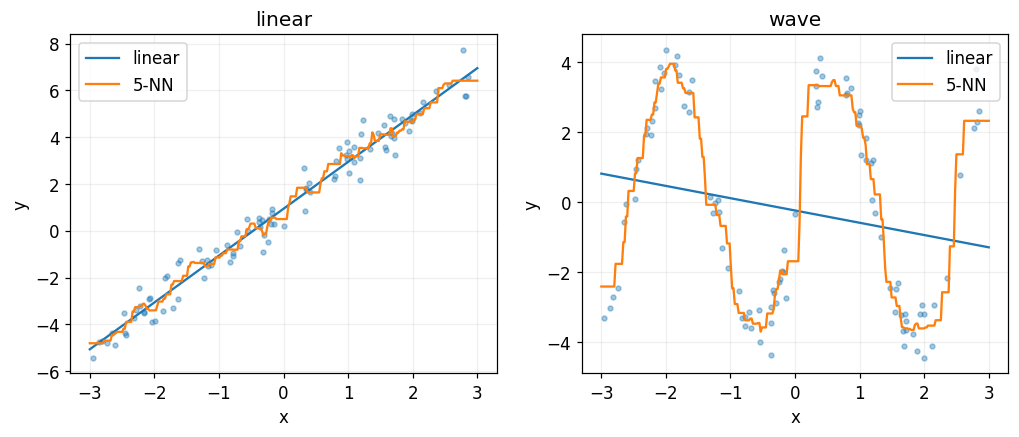

model,5-NN,linear
task,,
linear,0.562074,0.495331
wave,0.830120,2.845412


In [2]:
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, HuberRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
rng=np.random.default_rng(SEED)
xtrain=rng.uniform(-3,3,(100,1));xtest=rng.uniform(-3,3,(500,1));xline=np.linspace(-3,3,300)[:,None]
functions={'linear':lambda x:2*x[:,0]+1,'wave':lambda x:4*np.sin(2.5*x[:,0])}
rows=[];fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(name,f) in zip(axes,functions.items()):
    yt=f(xtrain)+rng.normal(0,.5,len(xtrain));yv=f(xtest)+rng.normal(0,.5,len(xtest))
    ax.scatter(xtrain,yt,s=10,alpha=.4)
    for model_name,estimator in [('linear',LinearRegression()),('5-NN',KNeighborsRegressor(5))]:
        estimator.fit(xtrain,yt)
        rows.append({'task':name,'model':model_name,'test_RMSE':root_mean_squared_error(yv,estimator.predict(xtest))})
        ax.plot(xline,estimator.predict(xline),label=model_name)
    ax.set(xlabel='x',ylabel='y',title=name);ax.legend()
savefig('08_inductive_bias')
pd.DataFrame(rows).pivot(index='task',columns='model',values='test_RMSE')

## 2. 故意犯錯：在 CV 外選特徵

純亂數的 X 與 y 沒有訊號。若先用所有標籤挑高相關特徵，再做 CV，驗證標籤已滲入特徵選擇。以下 `leaky` 是明示反例，不能移到正式流程；`proper` 在每折內選特徵。重複 8 組合成資料，報告每次結果，而不挑最誇張的一次。

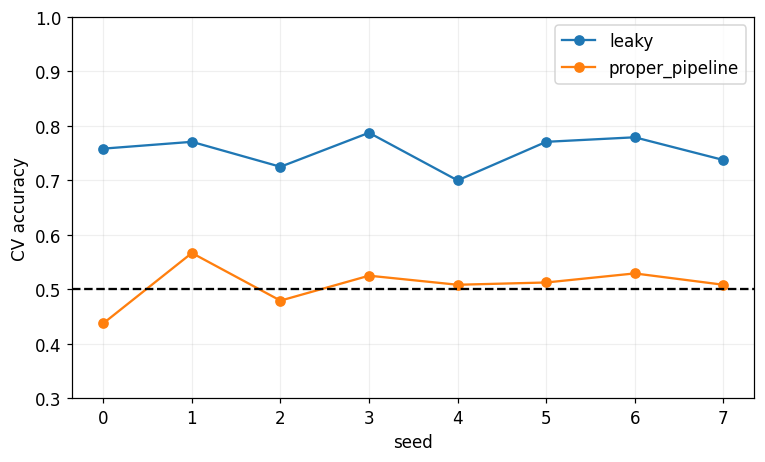

,leaky,proper_pipeline
seed,,
0,0.758333,0.437500
1,0.770833,0.566667
2,0.725000,0.479167
3,0.787500,0.525000
4,0.700000,0.508333
5,0.770833,0.512500
6,0.779167,0.529167
7,0.737500,0.508333


In [3]:
from sklearn.feature_selection import SelectKBest,f_classif
leak_rows=[]
for seed in range(8):
    rng=np.random.default_rng(seed)
    X=rng.normal(size=(240,2000));y=rng.integers(0,2,240)
    folds=list(StratifiedKFold(4,shuffle=True,random_state=SEED).split(X,y))
    estimator=LogisticRegression(max_iter=1000)
    X_leaky=SelectKBest(f_classif,k=20).fit_transform(X,y)  # 故意錯誤示範
    leaky=cross_val_score(estimator,X_leaky,y,cv=folds).mean()
    proper=cross_val_score(make_pipeline(SelectKBest(f_classif,k=20),estimator),X,y,cv=folds).mean()
    leak_rows.append({'seed':seed,'leaky':leaky,'proper_pipeline':proper})
leak_table=pd.DataFrame(leak_rows).set_index('seed')
leak_table.plot(marker='o');plt.axhline(.5,color='k',ls='--');plt.ylabel('CV accuracy');plt.ylim(.3,1)
savefig('08_feature_selection_leakage')
leak_table

## 3. 同一個人的資料分在兩邊：群組洩漏

合成 60 個群組，每組 8 筆。特徵含群組身分，標籤只由群組亂數決定。隨機拆列可記住同一組；GroupKFold 才問「沒見過的群組」能否預測。這對同一學生多次作答、同一病人多張影像、同一裝置多筆紀錄都提供驗證設計的提醒。

In [4]:
rng=np.random.default_rng(SEED)
groups=np.repeat(np.arange(60),8)
group_y=rng.integers(0,2,60);y=group_y[groups]
X=np.eye(60)[groups]+rng.normal(0,.005,(len(groups),60))
random_folds=list(StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y))
group_folds=list(GroupKFold(5).split(X,y,groups))
for tr,va in group_folds:
    assert not set(groups[tr])&set(groups[va])
knn=KNeighborsClassifier(3)
group_results={'random_row_CV':cross_val_score(knn,X,y,cv=random_folds).mean(),
               'unseen_group_CV':cross_val_score(knn,X,y,cv=group_folds).mean()}
pd.Series(group_results)

random_row_CV      1.000000
unseen_group_CV    0.477083
dtype: float64

## 4. 時間資料：讓訓練時間早於驗證時間

圖示比較 shuffled KFold 與 TimeSeriesSplit。後者逐步擴大過去資料，並在訓練與驗證間留 gap=3；gap 的實際長度應配合特徵視窗、標籤延遲與資料相依。這裡只驗證切分語意，沒有把一種切分的分數當成另一種任務的優劣。

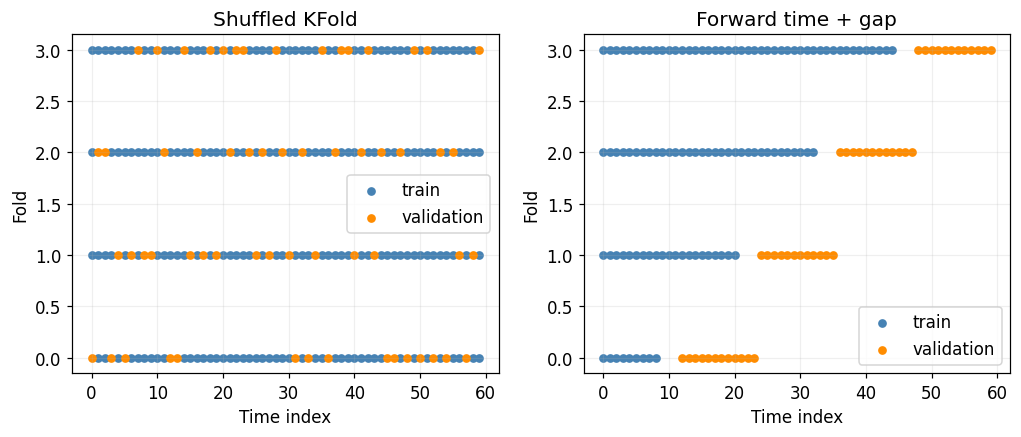

In [5]:
timeline=np.arange(60)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,(name,splitter) in zip(axes,[('Shuffled KFold',KFold(4,shuffle=True,random_state=SEED)),
                                  ('Forward time + gap',TimeSeriesSplit(4,gap=3))]):
    for fold,(tr,va) in enumerate(splitter.split(timeline)):
        if isinstance(splitter,TimeSeriesSplit):assert tr.max()<va.min()-3
        ax.scatter(tr,np.repeat(fold,len(tr)),c='steelblue',s=22,label='train' if fold==0 else None)
        ax.scatter(va,np.repeat(fold,len(va)),c='darkorange',s=22,label='validation' if fold==0 else None)
    ax.set(xlabel='Time index',ylabel='Fold',title=name);ax.legend()
savefig('08_group_time_splits')

## 5. Train-dev 幫忙區分過擬合與來源差異

在這個已知生成機制的例子裡，source 與 target 都遵循 $y=x^2+noise$，但 X 的分布改變（covariate shift）。source 的保留集稱為 train-dev；target-dev 模擬使用環境。只用 source training fit 一次線性模型，再觀察三種誤差。

target-dev 誤差變大是分布差異與線性模型假設共同作用。真實資料中，單靠這三個誤差不能唯一診斷漂移原因；還要檢查來源、標籤品質與抽樣方式。

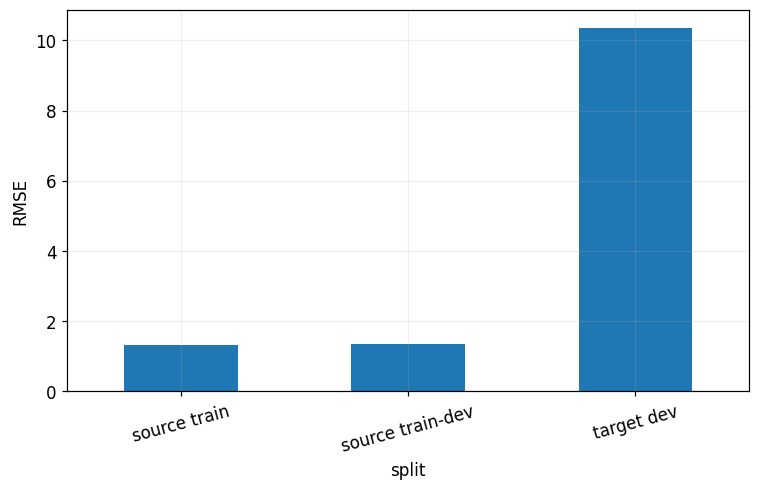

,split,RMSE,x_mean
0,source train,1.311260,-0.041079
1,source train-dev,1.358787,0.102490
2,target dev,10.337109,2.938995


In [6]:
rng=np.random.default_rng(SEED)
source_x=rng.normal(0,1,(400,1));source_y=source_x[:,0]**2+rng.normal(0,.4,400)
target_x=rng.normal(3,1,(160,1));target_y=target_x[:,0]**2+rng.normal(0,.4,160)
model=LinearRegression().fit(source_x[:300],source_y[:300])
mismatch=[]
for name,Xpart,ypart in [('source train',source_x[:300],source_y[:300]),
                         ('source train-dev',source_x[300:],source_y[300:]),
                         ('target dev',target_x,target_y)]:
    mismatch.append({'split':name,'RMSE':root_mean_squared_error(ypart,model.predict(Xpart)),'x_mean':Xpart.mean()})
pd.DataFrame(mismatch).set_index('split')['RMSE'].plot.bar();plt.xticks(rotation=15);plt.ylabel('RMSE')
savefig('08_data_mismatch')
pd.DataFrame(mismatch)

## 6. Concept drift：先預測，等標籤到來，再更新

X 的分布保持相同；第 2,000 筆起，真實關係從 $y=2x+noise$ 改成 $y=-2x+noise$，所以是概念漂移。凍結模型與增量模型都先在最初 500 筆訓練；逐批 100 筆 **先評估，再 partial_fit**。此例假設每批結束即取得真實標籤，不能直接套用到標籤延遲數月的場景。

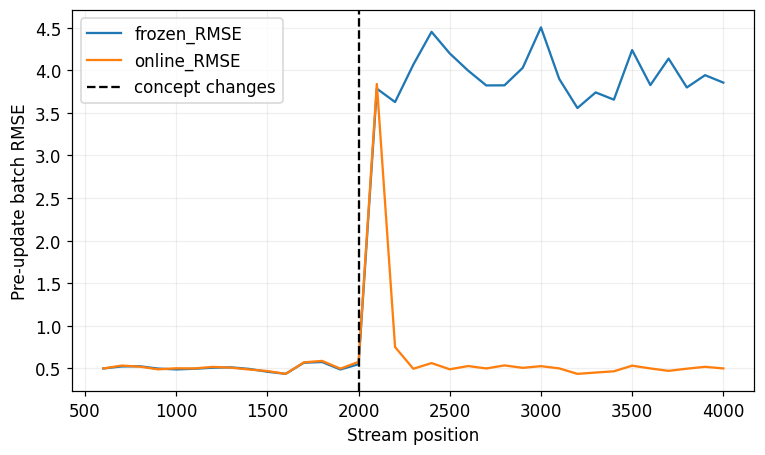

,frozen_RMSE,online_RMSE
batch_end,,
3600,3.825737,0.500352
3700,4.136937,0.471790
3800,3.798011,0.497442
3900,3.942188,0.519358
4000,3.855036,0.500502


In [7]:
import copy
rng=np.random.default_rng(SEED)
stream_x=rng.normal(0,1,(4000,1));coef=np.where(np.arange(4000)<2000,2.,-2.)
stream_y=coef*stream_x[:,0]+rng.normal(0,.5,4000)
initial=SGDRegressor(learning_rate='constant',eta0=.02,penalty=None,random_state=SEED,max_iter=1000,tol=1e-4)
initial.fit(stream_x[:500],stream_y[:500])
frozen=copy.deepcopy(initial);online=copy.deepcopy(initial);stream_rows=[]
for start in range(500,4000,100):
    xb=stream_x[start:start+100];yb=stream_y[start:start+100]
    # 不可交換順序：以下兩個指標都在 partial_fit 之前計算。
    stream_rows.append({'batch_end':start+100,'frozen_RMSE':root_mean_squared_error(yb,frozen.predict(xb)),
                        'online_RMSE':root_mean_squared_error(yb,online.predict(xb))})
    online.partial_fit(xb,yb)
stream_table=pd.DataFrame(stream_rows).set_index('batch_end')
stream_table.plot();plt.axvline(2000,color='k',ls='--',label='concept changes')
plt.xlabel('Stream position');plt.ylabel('Pre-update batch RMSE');plt.legend()
savefig('08_concept_drift')
stream_table.tail()

## 7. 極端誤差與穩健指標

RMSE 與 MAE 是評估量，Huber 是可用於訓練的損失之一。畫出對殘差的懲罰，再以帶離群 y 的訓練資料比較 OLS 與 Huber；獨立測試資料由原先乾淨機制生成。這個設定刻意適合穩健方法，不能推廣為所有資料的推薦。

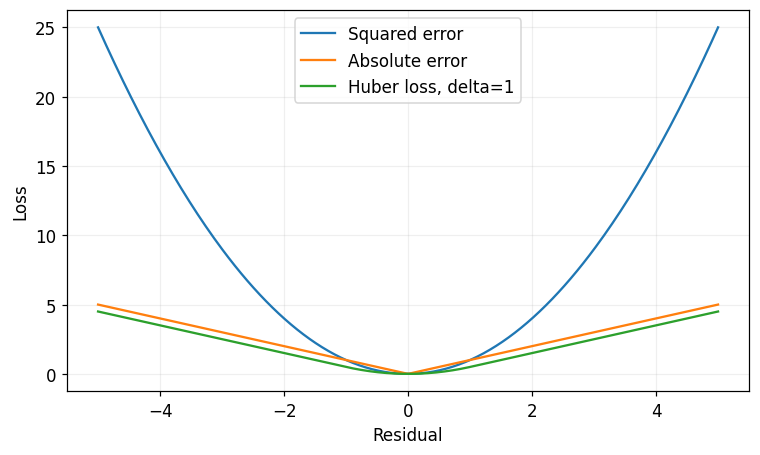

,model,test_RMSE,test_MAE
0,OLS,1.249312,1.049586
1,Huber,0.310303,0.249643


In [8]:
residual=np.linspace(-5,5,300);delta=1.
huber=np.where(np.abs(residual)<=delta,.5*residual**2,delta*(np.abs(residual)-.5*delta))
plt.plot(residual,residual**2,label='Squared error');plt.plot(residual,np.abs(residual),label='Absolute error')
plt.plot(residual,huber,label='Huber loss, delta=1');plt.xlabel('Residual');plt.ylabel('Loss');plt.legend()
savefig('08_robust_losses')
rng=np.random.default_rng(SEED)
X=rng.uniform(-2,2,(100,1));y=2*X[:,0]+1+rng.normal(0,.3,100);y[:8]+=12
X_eval=rng.uniform(-2,2,(300,1));y_eval=2*X_eval[:,0]+1+rng.normal(0,.3,300)
robust=[]
for name,est in [('OLS',LinearRegression()),('Huber',HuberRegressor())]:
    model=make_pipeline(StandardScaler(),est).fit(X,y);pred=model.predict(X_eval)
    robust.append({'model':name,'test_RMSE':root_mean_squared_error(y_eval,pred),'test_MAE':mean_absolute_error(y_eval,pred)})
pd.DataFrame(robust)

In [9]:
# y=0 時百分比誤差本來未定義；sklearn 以極小分母得到巨大有限值。
y_small=np.array([0.,.01,10.]);pred_small=np.array([1.,1.,11.])
print('MAE:',mean_absolute_error(y_small,pred_small))
print('MAPE ratio (not percent):',mean_absolute_percentage_error(y_small,pred_small))
print('Contains zero target:',bool(np.any(y_small==0)))
report('research_extensions',{'leakage_mean':leak_table.mean().to_dict(),'group_validation':group_results,
                              'mismatch':mismatch,'robust_models':robust,
                              'stream_last5_mean_RMSE':stream_table.tail().mean().to_dict()})

MAE: 0.9966666666666667
MAPE ratio (not percent): 1501199875790198.2
Contains zero target: True


## 延伸任務與參考答案

1. online learning 是否自動處理任何漂移？**否，更新速度、模型容量、標籤可得性、災難性遺忘與污染都會影響。**
2. 將隨機標籤實驗的特徵數從 2,000 改成 20，預期洩漏造成的樂觀幅度如何改變？**可搜尋的偶然相關變少，通常幅度較小，但仍須實測。**
3. 房價誤差的 bootstrap CI 能證明 A 模型顯著優於 B 嗎？**不能；需設計配對比較及明確假設，並考慮群組／時間相依與選模過程。**
4. MAPE 遇到 0 應直接加小常數嗎？**不能默默改分母；應依業務定義選指標或明示處理規則，並檢查對結論的影響。**

**報告格式：** 資料生成／來源 → 切分單位與時間 → fit 範圍 → 評估指標 → 重複實驗 → 不確定性 → 可支持與不可支持的結論。